In [143]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [144]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import celltrip


# Styling
mpl.rcParams['pdf.fonttype'] = mpl.rcParams['ps.fonttype'] = 42
sns.set_theme(context='paper', style='dark', palette='colorblind')

# Load Data and Policy

In [145]:
# Read data
adatas = [
    celltrip.utility.processing.merge_adatas(
        *celltrip.utility.processing.read_adatas(*[
            f's3://nkalafut-celltrip/Flysta3D/{p}_{m}.h5ad'
            for p in ('E14-16h_a', 'E16-18h_a', 'L1_a', 'L2_a', 'L3_b')
        ], backed=True), backed=True)
    for m in ('expression', 'spatial')]

In [146]:
# Load manager
prefix, training_step = 's3://nkalafut-celltrip/checkpoints/flysta-250909-4', 800
manager = celltrip.manager.BasicManager(
    policy_fname=f'{prefix}-{training_step:04}.weights',
    preprocessing_fname=f'{prefix}.pre',
    mask_fname=f'{prefix}.mask',
    device='cuda')

# Timepoint Interpolation

In [147]:
# Get L1_a and L3_b
sample_num = 1_000  # TODO: Use `celltrip.utility.processing.generate_pseudocells` instead of random sampling
np.random.seed(42)
start_idx = np.random.choice(
    np.where(adatas[0].obs['development'] == 'L1_a')[0], sample_num, replace=False)
start_modalities = [adata[start_idx] for adata in adatas]
end_idx = np.random.choice(
    np.where(adatas[0].obs['development'] == 'L3_b')[0], sample_num, replace=False)
end_modalities = [adata[end_idx] for adata in adatas]

In [148]:
# Simulate start state
manager.set_modalities(start_modalities[:1])
manager.reset_env()
manager.simulate();

/tmp/ipykernel_3296/3679472040.py:2: UserWarning: Creating new environment due to mismatched modalities
  manager.set_modalities(start_modalities[:1])
100%|██████████| 5120/5120 [00:14<00:00, 353.05it/s]


In [149]:
# Simulate from steady start to terminal state
# NOTE: Longer simulations may dilute the mapping and spread out transition time,
#       which is a problem to be solved in the future
manager.set_modalities(end_modalities[:1])
time, states = manager.simulate(time=512., skip_time=.1, impute=False, include_vel=True);

100%|██████████| 5120/5120 [00:15<00:00, 322.14it/s]


# Perform Mapping

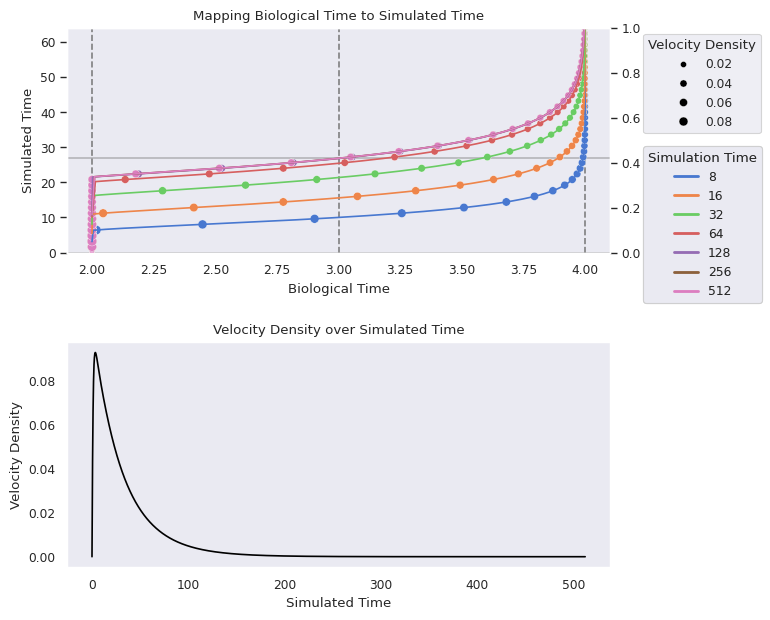

In [177]:
# Make figure
fig, axs = plt.subplots(2, 1, figsize=(7, 7))
fig.subplots_adjust(hspace=.4)

# Plot time mapping over multiple timeframes
ax = axs[0]
for i, (end_time, color) in enumerate(zip([8, 16, 32, 64, 128, 256, 512], sns.color_palette('muted', 7))):
    end_idx = int(len(time)*end_time//max(time))
    vel_density = states[..., manager.dim:].abs().mean(dim=(-1, -2))
    map_func = celltrip.utility.mapping.compute_sim_bio_mapping(vel_density[:end_idx], time[:end_idx], start_val=2, end_val=4)
    bio_time = map_func(time)
    sim_vel_density = states[..., manager.dim:].mean(dim=-1).mean(dim=-1)
    df = pd.DataFrame({
        'Biological Time': bio_time,
        'Simulated Time': time,
        'Velocity Density': sim_vel_density})
    sns.lineplot(
        data=df,
        x='Biological Time',
        y='Simulated Time',
        color=color,
        alpha=1.,
        legend=False,
        ax=ax)
    sns.scatterplot(
        data=df.iloc[::16],
        x='Biological Time',
        y='Simulated Time',
        size='Velocity Density',
        color=color,
        alpha=1.,
        legend=i==0,
        ax=ax)
ax.set_title('Mapping Biological Time to Simulated Time')
ax.set_ylim(0, 64)

# Move legend and change all points to be black
sns.move_legend(ax, 'upper left', bbox_to_anchor=(1.05, 1))
for handle in ax.legend_.legend_handles:
    handle.set_markerfacecolor('black')

# Add another legend for the line colors
axc = ax.twinx()
from matplotlib.lines import Line2D
line_legend = axc.legend(
    handles=[Line2D([0], [0], color=color, lw=2) for color in sns.color_palette('muted', 7)],
    labels=[f'{end_time}' for end_time in [8, 16, 32, 64, 128, 256, 512]],
    title='Simulation Time',
    loc='upper left',
    bbox_to_anchor=(1.05, 0.5))
axc.add_artist(line_legend)

# Draw horizontal lines at intersections with known timepoints
for i in np.searchsorted(bio_time, [2, 3, 4]):
    ax.axhline(
        time[i if i < len(time) else -1],
        linestyle='-',
        color='gray',
        alpha=.5,
        zorder=-1)

# Annotate
margin, height = .05, df['Simulated Time'].max() * .9
ax.axvline(2, color='gray', linestyle='--', zorder=-1)
ax.annotate('L1_a', xy=(2+margin, height), bbox=dict(boxstyle='round', fc='white', ec='gray'))
ax.axvline(3, color='gray', linestyle='--', zorder=-1)
ax.annotate('L2_a', xy=(3+margin, height), bbox=dict(boxstyle='round', fc='white', ec='gray'))
ax.axvline(4, color='gray', linestyle='--', zorder=-1)
ax.annotate('L3_b', xy=(4-margin, height), bbox=dict(boxstyle='round', fc='white', ec='gray'), ha='right')

# Plot velocity density over time
ax = axs[1]
sns.lineplot(
    data=df,
    x='Simulated Time',
    y='Velocity Density',
    color='black',
    ax=ax)
ax.set_title('Velocity Density over Simulated Time');

In [ ]:
def find_target_bio_time(map_func, target_time, max_iter=1000, tol=1e-5):
    # Use exponential search to find an upper bound
    low, high = 0, 1
    for _ in range(max_iter):
        if map_func(high) >= target_time: break
        low, high = high, high * 2

    # Use binary search on interval
    for _ in range(max_iter):
        mid = (low + high) / 2
        if abs(map_func(mid) - target_time) < tol or low >= high:
            return mid
        if map_func(mid) < target_time:
            low = mid
        else:
            high = mid

    return mid

In [ ]:
find_target_bio_time(f, 3.5)

29.911376953125